# CSCI E-89 Deep Learning: Assignment 03, Problem 3

**Andra Constandache**

## FashionMNIST Image Classifier in PyTorch

This notebook builds, trains and evaluates a multilayer perceptron (MLP) that classifies FashionMNIST clothing images into 10 classes. It follows the section "Building an Image Classifier with PyTorch" in Geron, *Hands-On Machine Learning*, chapter 10, with the same variable names, seeds and helper functions.

Steps:
1. Load and split the data
2. Build the model
3. Train the model
4. Plot the training accuracy
5. Predict new images

## 1. Load and split the data

### Imports
PyTorch, TorchVision (datasets and `transforms.v2`), torchmetrics for accuracy, and matplotlib for plots.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

### Load FashionMNIST
`ToImage()` converts each image into a tensor of shape `[1, 28, 28]` (channels, height, width). `ToDtype(torch.float32, scale=True)` casts pixels to float32 and scales them to [0, 1]. The data downloads into `./datasets` on the first run.

In [2]:
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

### Split into training and validation sets
The 60,000 training images are split into 55,000 for training and 5,000 for validation. `torch.manual_seed(42)` makes the split reproducible.

In [3]:
torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

print(f"Train size: {len(train_data)}")
print(f"Valid size: {len(valid_data)}")
print(f"Test size:  {len(test_data)}")

Train size: 55000
Valid size: 5000
Test size:  10000


### Inspect one sample
Each sample is an `(image, target)` tuple. The image is a `[1, 28, 28]` float32 tensor and the target is a class index from 0 to 9.

In [4]:
X_sample, y_sample = train_data[0]
print(f"Sample shape: {X_sample.shape}, dtype: {X_sample.dtype}")
print(f"Sample class: {y_sample} ({train_and_valid_data.classes[y_sample]})")

Sample shape: torch.Size([1, 28, 28]), dtype: torch.float32
Sample class: 9 (Ankle boot)


### Build the DataLoaders
DataLoaders serve mini-batches of 32 images. Only the training set is shuffled. The seed is set again, as in Geron, so the shuffle order is reproducible.

In [5]:
torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

X_batch, y_batch = next(iter(train_loader))
print(f"Batch images: {X_batch.shape}, dtype: {X_batch.dtype}")
print(f"Batch labels: {y_batch.shape}, dtype: {y_batch.dtype}")

Batch images: torch.Size([32, 1, 28, 28]), dtype: torch.float32
Batch labels: torch.Size([32]), dtype: torch.int64


## 2. Build the model

### Select the device
An NVIDIA GPU (`cuda`) or Apple GPU (`mps`) is used if available, otherwise the CPU.

In [6]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Device: {device}")

Device: cpu


### Define the classifier
`Flatten` turns each `[1, 28, 28]` image into a 784-value vector. Two hidden layers (300 and 100 units, ReLU) are followed by an output layer with one logit per class. No softmax is applied: `CrossEntropyLoss` applies it internally.

In [7]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)

torch.manual_seed(42)
model = ImageClassifier(n_inputs=28 * 28, n_hidden1=300, n_hidden2=100,
                        n_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()

print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)
Parameters: 266,610


### Check one forward pass
The output for one batch has shape `[32, 10]`. The untrained loss is close to ln(10) = 2.30, the value for random guessing over 10 classes.

In [8]:
X_batch, y_batch = X_batch.to(device), y_batch.to(device)
with torch.no_grad():
    y_pred = model(X_batch)
print(f"Output shape: {y_pred.shape}")
print(f"Initial loss: {xentropy(y_pred, y_batch).item():.4f}")

Output shape: torch.Size([32, 10])
Initial loss: 2.3086


## 3. Train the model

### Helper functions
`evaluate_tm()` computes a torchmetrics metric over a full DataLoader. `train2()` runs mini-batch gradient descent for `n_epochs` and records the training loss, training accuracy and validation accuracy after each epoch.

In [9]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()


def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
           n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

### Train for 20 epochs
Plain SGD with learning rate 0.1. Multiclass accuracy is the tracked metric. Training takes a few minutes on a CPU.

In [10]:
n_epochs = 20
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

history = train2(model, optimizer, xentropy, accuracy, train_loader,
                 valid_loader, n_epochs)

Epoch 1/20, train loss: 0.6060, train metric: 0.7814, valid metric: 0.8424


Epoch 2/20, train loss: 0.4061, train metric: 0.8496, valid metric: 0.8402


Epoch 3/20, train loss: 0.3630, train metric: 0.8661, valid metric: 0.8494


Epoch 4/20, train loss: 0.3355, train metric: 0.8768, valid metric: 0.8638


Epoch 5/20, train loss: 0.3154, train metric: 0.8829, valid metric: 0.8782


...

Epoch 16/20, train loss: 0.2078, train metric: 0.9196, valid metric: 0.8886


Epoch 17/20, train loss: 0.2033, train metric: 0.9233, valid metric: 0.8870


Epoch 18/20, train loss: 0.1991, train metric: 0.9230, valid metric: 0.8846


Epoch 19/20, train loss: 0.1916, train metric: 0.9266, valid metric: 0.8812


Epoch 20/20, train loss: 0.1876, train metric: 0.9286, valid metric: 0.8788


### Final accuracy
Training and validation accuracy after the last epoch.

In [11]:
print(f"Final train accuracy: {history['train_metrics'][-1]:.4f}")
print(f"Final valid accuracy: {history['valid_metrics'][-1]:.4f}")

Final train accuracy: 0.9286
Final valid accuracy: 0.8788


## 4. Plot the training accuracy
Training accuracy per epoch. It rises fast in the first epochs, then more slowly.

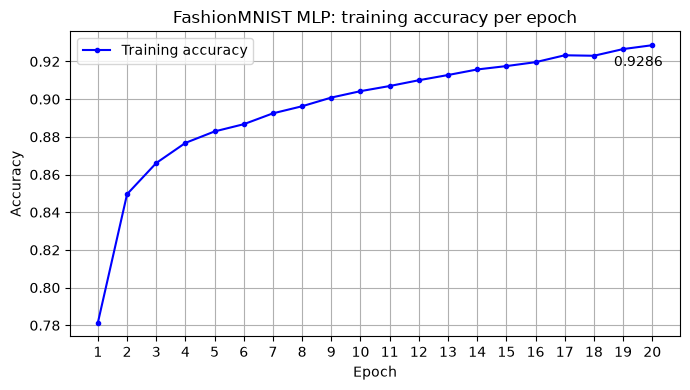

In [12]:
train_acc = history["train_metrics"]
epochs = range(1, n_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, train_acc, "b.-", label="Training accuracy")
plt.annotate(f"{train_acc[-1]:.4f}", (epochs[-1], train_acc[-1]),
             textcoords="offset points", xytext=(-10, -15), ha="center")
plt.xticks(list(epochs))
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FashionMNIST MLP: training accuracy per epoch")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Predict new images
The first 3 validation images are classified. The predicted class is the one with the highest logit, and softmax gives its probability (confidence).

In [13]:
model.eval()
X_new, y_new = next(iter(valid_loader))
X_new, y_new = X_new[:3].to(device), y_new[:3]
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1).cpu()
y_proba = F.softmax(y_pred_logits, dim=1).cpu()

class_names = train_and_valid_data.classes
for i in range(3):
    print(f"Image {i + 1}: predicted {class_names[y_pred[i]]} "
          f"({y_proba[i, y_pred[i]]:.1%}), true {class_names[y_new[i]]}")

Image 1: predicted Sneaker (85.9%), true Sneaker
Image 2: predicted Coat (99.3%), true Coat
Image 3: predicted Pullover (59.2%), true Pullover


### Show the predictions
Each image with its predicted label (and confidence) and its true label. Green titles are correct predictions, red titles are wrong.

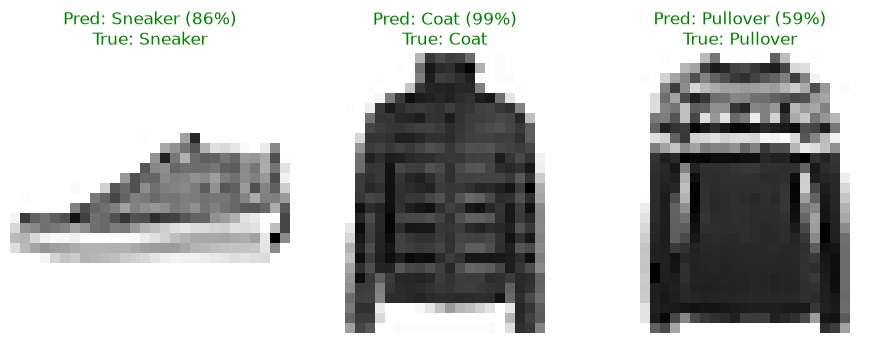

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3.5))
for i, ax in enumerate(axes):
    ax.imshow(X_new[i, 0].cpu(), cmap="binary")
    correct = y_pred[i] == y_new[i]
    ax.set_title(f"Pred: {class_names[y_pred[i]]} ({y_proba[i, y_pred[i]]:.0%})\n"
                 f"True: {class_names[y_new[i]]}",
                 color="green" if correct else "red")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Conclusion
The MLP reaches about 93% training accuracy and about 88% validation accuracy after 20 epochs. Validation accuracy levels off after roughly 10 epochs while training accuracy keeps rising, which indicates mild overfitting.